# Import libs

In [1]:
from regime_identification.Features.features import get_log
from regime_identification.Features.regimes import expanding_norm, get_pca, scree_pca, plot_clusters
from regime_identification.Data.yf_tickers import load, load_prices

import pandas as pd
import numpy as np
from datetime import datetime, timedelta, date
import yaml

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm # Loading bars

In [2]:
# Ignore performance warnings from pandas
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

# Data retrieval

In [3]:
processed_dir = "../Data/Processed"

config = yaml.safe_load(open("config.yml"))
etfs = load_prices(f"{processed_dir}/ETFs/")
full = load(f"{processed_dir}/regime_clusters.csv")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:00<00:00, 32.07it/s]


# Testing validation

As we did our analyses in the training dataset (pre-2019), we now want to validate the observations in unseen test data (post-2019). 

In [4]:
split_date = pd.to_datetime(date(*config["SPLIT_DATE"]))

## Backtesting

We can evaluate performance of our strategy by summing the next-day-closing returns for our holdings each day (or subtracting when taking a short position). Then, we compare to our defualt-stock benchmark (BM), just hold all (JH) and/or random buys (RB) strategies to assess performance.

In [5]:
from regime_identification.Modelling.backtesting import backtest_strategies

### Long-Short portfolio

A simple way to exploit our regime information is to **long predicted overperformers and short underperformers**. This would mean we:
- Regime 0: Long govt & corporate bonds (TLT & LQD); Short oil (USO) (and possibly also nuclear (URA) & agriculture (DBA))
- Regime 1: Long gold (GLD) & DBA; Possibly short TLT
- Regime 2: Long emerging markets (VWO);
- Regime 3: Long USO;

In [6]:
'''
The "strategy" is a df where each column is a condition (here: regime) and each row an asset.
Location [asset, condition] represents how much of an asset to buy in that condition.
Values indicate the ratio of the portfolio to allocate to the asset proportional to other assets. 
Ratios are adjusted to total an absolute value of 1 per condition.
'''

etfs_names = list(etfs.keys())
n_clusters = config["N_CLUSTERS"] 

strategy = pd.DataFrame(np.nan, index = etfs_names, columns = np.arange(n_clusters))

# Regime 0: Long TLT & LQD; Short USO
strategy.loc[["TLT", "LQD"], 0] = 1
strategy.loc[["USO"], 0] = -1 # We could select a higher ratio, as we have very strong conclusions for USO specifically

# Regime 1: Long GLD & DBA; Short TLT
strategy.loc[["GLD", "DBA"], 1] = 1
strategy.loc[["TLT"], 1] = -1

# Regime 2: Long VWO
strategy.loc[["VWO"], 2] = 3 # Sum everything to 3 for some easier strategy additions later

# Regime 3: Long USO
strategy.loc[["USO"], 3] = 3

In [7]:
strategy.dropna(how = "all") # Visual representation of our strategy

,0,1,2,3
USO,-1.0,NaN,NaN,3.0
GLD,NaN,1.0,NaN,NaN
LQD,1.0,NaN,NaN,NaN
VWO,NaN,NaN,3.0,NaN
TLT,1.0,-1.0,NaN,NaN
DBA,NaN,1.0,NaN,NaN


In [8]:
# Benchmark strategies
jh = pd.DataFrame(1, index = etfs_names, columns = np.arange(n_clusters)) # hold all
bm = pd.DataFrame(1, index = ["RSP"], columns = np.arange(n_clusters)) # RSP only

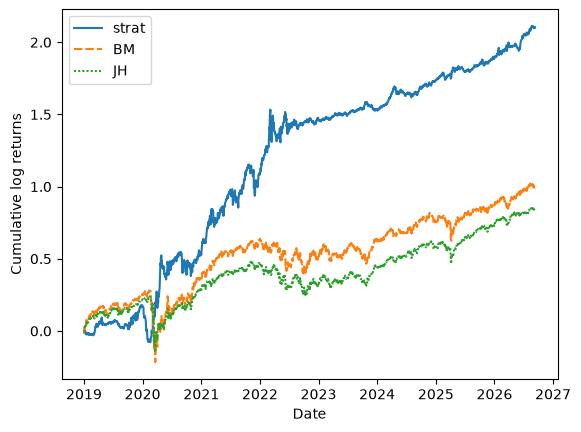

In [9]:
strat_dfs = backtest_strategies(etfs, condition_col = "cluster",
                                  strategies = {"strat": strategy, "BM": bm, "JH": jh},
                                  start_date = split_date, plot = True)

In [10]:
def get_performance(df): # Make sure df is in logret
    # Replace 0 with nan
    df = df["total"]

    ret = np.exp(df.sum() - 1)
    ret = np.exp(df) - 1
    sharpe = ret.mean() * np.sqrt(252) / ret.std() # annualize for readability
    sortino = ret.mean() * np.sqrt(252) / ret[ret < 0].std()

    print(f"total return: {int(ret.sum() * 100)}%\nannual return: {int(ret.sum() * 100 * 252 / len(df))}%\nsharpe: {sharpe}\nsortino: {sortino}")    

In [11]:
for name, df in strat_dfs.items():
    print(f"\n{name}:")
    get_performance(df)


strat:
total return: 230%
annual return: 29%
sharpe: 1.320623656480945
sortino: 1.6136602078335187

BM:
total return: 113%
annual return: 14%
sharpe: 0.7478334768143262
sortino: 0.9245171173517158

JH:
total return: 92%
annual return: 12%
sharpe: 0.7801762456617022
sortino: 0.9223070065859028


WOW! We hypothetically outperformed the market by quite a large margin, both in raw return and risk-adjusted returns.

### Long-Short + exposure portfolio

There are significant risks associated with the previous Long-Short portfolio: **Lack of diversification** (in some regimes)

We lose out on a significant level of market exposure, as well as exposing ourselves to issues with non-diversified risk such as [the turkey illusion](https://en.wikipedia.org/wiki/Turkey_illusion) (especially in regime 2 and 3). This can be **mediated by investing in a "default" stock** and diversifying our market exposure risk with the addition of our long-short strategy. 

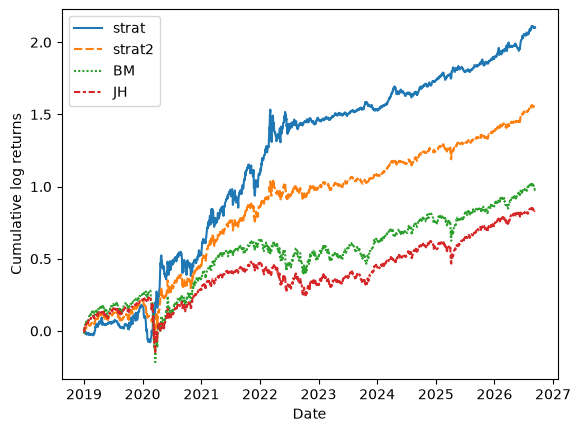

In [12]:
# Add a default stock
strategy2 = strategy.copy()
strategy2.loc[["RSP"], :] = 3 # 50% in RSP, 50% in our strategy

# Test again
strat_dfs = backtest_strategies(etfs, condition_col = "cluster",
                                  strategies = {"strat": strategy, "strat2": strategy2, "BM": bm, "JH": jh},
                                  start_date = split_date, plot = True)

In [13]:
for name, df in strat_dfs.items():
    print(f"\n{name}:")
    get_performance(df)


strat:
total return: 230%
annual return: 29%
sharpe: 1.320623656480945
sortino: 1.6136602078335187

strat2:
total return: 163%
annual return: 21%
sharpe: 1.3785981263140419
sortino: 1.7513716688773062

BM:
total return: 113%
annual return: 14%
sharpe: 0.7478334768143262
sortino: 0.9245171173517158

JH:
total return: 92%
annual return: 12%
sharpe: 0.7801762456617022
sortino: 0.9223070065859028


While the total return for our exposure strategy is not as high as the pure Long-Short portfolio, it does have a **better risk-adjusted return** in both Sharpe and Sortino ratio.

### Maximum diversification portfolio

We can alternatively exploit information on between-asset correlation during regimes to maximize diversification and reduce exposure to market fluctuations (e.g. optimize sharp/sortino through minimizing volatility). This could be especially interesting to explore with leveraged positions as a way to minimize drawdowns.

Concretely:
- Regime 0: Long XLP & LQD; (Weight LQD higher because better estimated return)
- Regime 1: Long GLD, LQD, XLP; Short TLT; (VNQ is zero) (Higher weights for GLD & TLT)
- ~~Regime 2: GLD, EMB, LQD, USO, XBI, XLU, DBA, XLV, XLK~~ (Not identified post-2018 anyways)
- Regime 3: Long LQD, XLP, XLU; (TLT is zero)

In [14]:
corr_strat = pd.DataFrame(np.nan, index = etfs_names, columns = np.arange(n_clusters))

# Regime 0: ++ LQD; + XLP
corr_strat.loc["XLP", 0] = 1
corr_strat.loc["LQD", 0] = 2

# Regime 1: ++ GLD; + LQD, XLP; -- TLT
corr_strat.loc["GLD", 1] = 2
corr_strat.loc[["LQD", "XLP"], 1] = 1
corr_strat.loc["TLT", 1] = -2

# Regime 2: NaN (not identified in 2019 anyways)

# Regime 3: + LQD, XLP, XLU
corr_strat.loc[["LQD", "XLP", "XLU"], 3] = 1

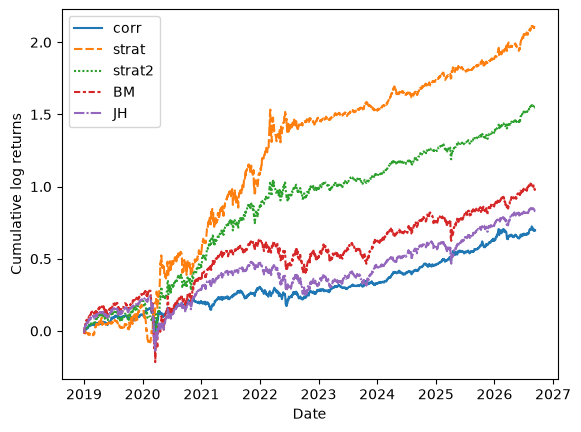

In [15]:
# Test again
strat_dfs = backtest_strategies(etfs, condition_col = "cluster",
                                  strategies = {"corr": corr_strat, "strat": strategy, "strat2": strategy2, "BM": bm, "JH": jh},
                                  start_date = split_date, plot = True)

In [16]:
for name, df in strat_dfs.items():
    print(f"\n{name}:")
    get_performance(df)


corr:
total return: 73%
annual return: 9%
sharpe: 0.9786182592670077
sortino: 1.1848715134476624

strat:
total return: 230%
annual return: 29%
sharpe: 1.320623656480945
sortino: 1.6136602078335187

strat2:
total return: 163%
annual return: 21%
sharpe: 1.3785981263140419
sortino: 1.7513716688773062

BM:
total return: 113%
annual return: 14%
sharpe: 0.7478334768143262
sortino: 0.9245171173517158

JH:
total return: 92%
annual return: 12%
sharpe: 0.7801762456617022
sortino: 0.9223070065859028


While we lose out on gains compared to other strategies, we still outperform the BM and JH in risk-adjusted returns

# Long-Short diversification hybrid

Combining our strongest predicted performers with additional uncorrelated assets to mitigate risk during drawdowns/false predictions.

In [17]:
corr_strat2 = pd.DataFrame(np.nan, index = etfs_names, columns = np.arange(n_clusters))

# Regime 0: Long TLT & LQD; Short USO
corr_strat2.loc[["TLT", "LQD"], 0] = 2
corr_strat2.loc[["USO"], 0] = -2 # We could select a higher ratio, as we have very strong conclusions for USO specifically
## Diversification
corr_strat2.loc["XLP", 0] = 1

# Regime 1: Long GLD & DBA; Short TLT
corr_strat2.loc[["GLD", "DBA"], 1] = 2
corr_strat2.loc[["TLT"], 1] = -2
## Diversification
corr_strat2.loc[["LQD", "XLP"], 1] = 1

# Regime 2: Long VWO (not identified anyways)
# strategy.loc[["VWO"], 2] = 3 # Sum everything to 3 for some easier strategy additions later

# Regime 3: Long USO
corr_strat2.loc[["USO"], 3] = 3
## Diversification
corr_strat2.loc[["LQD", "XLP", "XLU"], 3] = 1

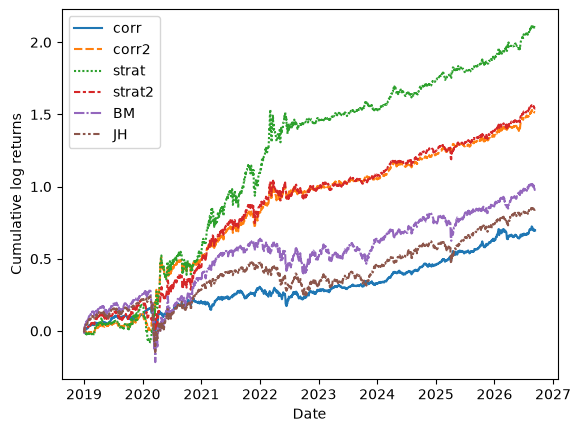

In [43]:
# Test again
strat_dfs = backtest_strategies(etfs, condition_col = "cluster",
                                  strategies = {"corr": corr_strat, "corr2": corr_strat2, "strat": strategy, "strat2": strategy2, "BM": bm, "JH": jh},
                                  start_date = split_date, plot = True)

In [44]:
for name, df in strat_dfs.items():
    print(f"\n{name}:")
    get_performance(df)


corr:
total return: 73%
annual return: 9%
sharpe: 0.9786182592670077
sortino: 1.1848715134476624

corr2:
total return: 159%
annual return: 20%
sharpe: 1.4625412192100282
sortino: 1.894671144895414

strat:
total return: 230%
annual return: 29%
sharpe: 1.320623656480945
sortino: 1.6136602078335187

strat2:
total return: 163%
annual return: 21%
sharpe: 1.3785981263140419
sortino: 1.7513716688773062

BM:
total return: 113%
annual return: 14%
sharpe: 0.7478334768143262
sortino: 0.9245171173517158

JH:
total return: 92%
annual return: 12%
sharpe: 0.7801762456617022
sortino: 0.9223070065859028


We achieved a **similar return to the RSP diversification strat** but with **the best sharpe/sortino ratio so far**.

# Benchmark-Adjusted performance

By subtracting the returns from a selected benchmark, we can view benchmark-adjusted returns of our strategies

In [67]:
# Adjust for benchmark
benchmark = "BM"
bm_total = strat_dfs[benchmark]["total"]

def adjust_strat_earnings(strat_dfs, bm_total):
    results = {}
    for ticker, df in strat_dfs.items():
        strat_total = df["total"]
        result = strat_total - bm_total
        results[ticker] = result
    return results

adj_strats = adjust_strat_earnings(strat_dfs, bm_total)
adj_strats.pop(benchmark)

Date
2019-01-02    0.0
2019-01-03    0.0
2019-01-04    0.0
2019-01-07    0.0
2019-01-08    0.0
             ... 
2026-09-04    0.0
2026-09-08    0.0
2026-09-09    0.0
2026-09-10    0.0
2026-09-11    0.0
Name: total, Length: 1934, dtype: float64

<Axes: xlabel='Date'>

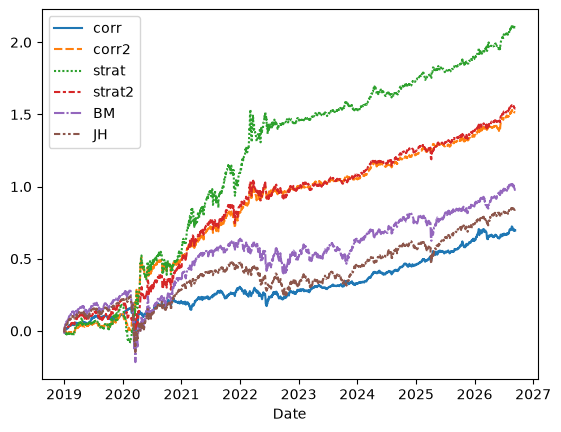

In [68]:
sns.lineplot(adj_cat.drop("cluster", axis = 1).cumsum())

In [69]:
# concat adjusted strats dict & add clusters
adj_cat = pd.concat(adj_strats, axis = 1)
adj_cat = adj_cat.join(full["cluster"])
# adj_cat = adj_cat.reset_index()

<Axes: xlabel='cluster', ylabel='value'>

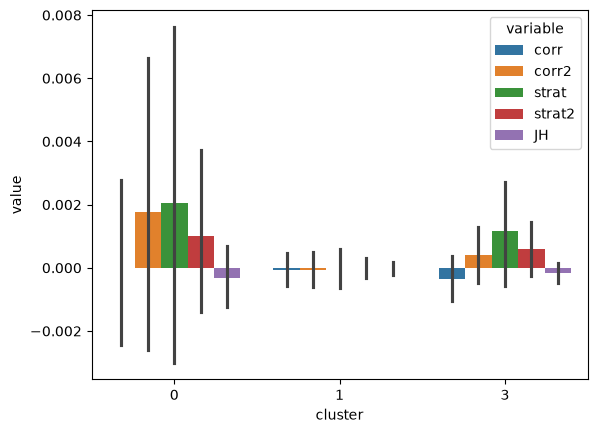

In [70]:
# Plot mean benchmark-adjusted earnings
sns.barplot(data = adj_cat.melt(id_vars = "cluster"), x = "cluster", y = "value", hue = "variable")

We can see clearly now that in our training data, the difference between our strategy and the benchmark is in regimes 0 and 3. Furthermore, we see that in cluster 1 there is not really an observable difference in returns between our strategies. Regime 1 seems to indicate a period of steady sustained growth accross asset classes (this is also observable in our training data). As such, it may be advisable to invest in a benchmark-like asset or strongly diversify during regime 1 in actual implementation.

# Leverage test (for fun)

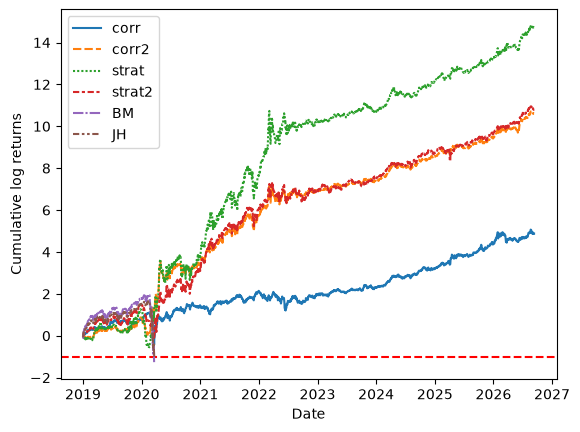

In [20]:
# Test leverage
strat_dfs = backtest_strategies(etfs, condition_col = "cluster",
                                strategies = {"corr": corr_strat, "corr2": corr_strat2, "strat": strategy, "strat2": strategy2, "BM": bm, "JH": jh},
                                start_date = split_date, plot = True,
                                leverage = 7)